# Fetch and Analyze Baseline Metrics

This notebook fetches Prometheus metrics for your Kubernetes cluster and prepares data for AI model training.

In [15]:
# Import Libraries
import requests
import pandas as pd
from datetime import datetime, timedelta
import os

# Configuration
PROM_URL = "http://localhost:9090"  # Update if using port-forward or different IP
STEP = "15s"  # Resolution of your data
LOOKBACK_HOURS = 1  # Last 1 hour

# Define the metric queries
QUERIES = {
    "cpu_usage": 'sum(rate(container_cpu_usage_seconds_total{pod=~"prime-service-deployment-.*",container!=""}[1m]))',
    "mem_usage_mb": 'sum(container_memory_usage_bytes{pod=~"prime-service-deployment-.*",container!=""}) / (1024*1024)',
    "app_rps_1m": 'sum(rate(http_request_duration_seconds_count[1m]))',
    "app_rps_irate": 'sum(irate(http_request_duration_seconds_count[30s]))', #insta RPS
    "ingress_rps_1m": 'sum(rate(nginx_ingress_controller_requests[1m]))',
    "rps_diff_1m": 'abs(sum(rate(http_request_duration_seconds_count[1m])) - sum(rate(nginx_ingress_controller_requests[1m])))',
    "app_p99_latency": 'histogram_quantile(0.99, sum by (le) (rate(http_request_duration_seconds_bucket{service="prime-service"}[2m])))',
    "ingress_p50_latency": 'histogram_quantile(0.50, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[2m])))',
    "ingress_p75_latency": 'histogram_quantile(0.75, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[2m])))',
    "ingress_p95_latency": 'histogram_quantile(0.95, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[2m])))',
    "ingress_p99_latency": 'histogram_quantile(0.99, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[2m])))',
    "nginx_active_conn": 'sum(nginx_ingress_controller_nginx_process_connections{state=~"active"})',
    "nginx_writing_conn": 'sum(nginx_ingress_controller_nginx_process_connections{state=~"writing"})',
    "latency_gap": 'abs(histogram_quantile(0.99, sum by (le) (rate(http_request_duration_seconds_bucket{service="prime-service"}[1m]))) - histogram_quantile(0.95, sum by (le) (rate(nginx_ingress_controller_request_duration_seconds_bucket{ingress="ingress-backend"}[1m]))))'
}

print("Configuration loaded!")

Configuration loaded!


In [16]:
# Define Functions

def fetch_metric_range(query, start, end, step):
    """Fetch metric data from Prometheus"""
    endpoint = f"{PROM_URL}/api/v1/query_range"
    params = {
        "query": query,
        "start": start,
        "end": end,
        "step": step
    }
    response = requests.get(endpoint, params=params)
    response.raise_for_status()
    data = response.json()
    
    # Process results into a dictionary of {timestamp: value}
    results = {}
    if data['data']['result']:
        for timestamp, value in data['data']['result'][0]['values']:
            results[int(timestamp)] = float(value)
    return results

def fetch_all_metrics(lookback_hours=LOOKBACK_HOURS):
    """Fetch all metrics for the specified lookback period"""
    end_time = int(datetime.now().timestamp())
    start_time = int((datetime.now() - timedelta(hours=lookback_hours)).timestamp())
    
    print(f"Fetching data from {datetime.fromtimestamp(start_time)} to {datetime.fromtimestamp(end_time)}...")
    
    all_data = {}
    
    for name, query in QUERIES.items():
        print(f"Fetching: {name}")
        try:
            all_data[name] = fetch_metric_range(query, start_time, end_time, STEP)
        except Exception as e:
            print(f"Error fetching {name}: {e}")
    
    # Convert to DataFrame with aligned timestamps
    df = pd.DataFrame(all_data)
    df.index = pd.to_datetime(df.index, unit='s')
    df = df.sort_index()
    
    # Fill missing values
    df = df.interpolate(method='linear').fillna(0)
    
    return df

print("Functions defined!")

Functions defined!


In [17]:
# Fetch Metrics and Save to CSV

# Fetch all metrics
df = fetch_all_metrics(LOOKBACK_HOURS)

# Display info

print(f"\n✅ Data fetched successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

# Save to CSV
filename = f"k8s_metrics_baseline_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
df.to_csv(filename)
print(f"\n💾 Dataset saved to: {filename}")

Fetching data from 2026-04-07 15:37:49 to 2026-04-07 16:37:49...
Fetching: cpu_usage
Fetching: mem_usage_mb
Fetching: app_rps_1m
Fetching: app_rps_irate
Fetching: ingress_rps_1m
Fetching: rps_diff_1m
Fetching: app_p99_latency
Fetching: ingress_p50_latency
Fetching: ingress_p75_latency
Fetching: ingress_p95_latency
Fetching: ingress_p99_latency
Fetching: nginx_active_conn
Fetching: nginx_writing_conn
Fetching: latency_gap

✅ Data fetched successfully!
Shape: (241, 14)
Columns: ['cpu_usage', 'mem_usage_mb', 'app_rps_1m', 'app_rps_irate', 'ingress_rps_1m', 'rps_diff_1m', 'app_p99_latency', 'ingress_p50_latency', 'ingress_p75_latency', 'ingress_p95_latency', 'ingress_p99_latency', 'nginx_active_conn', 'nginx_writing_conn', 'latency_gap']

First few rows:
                     cpu_usage  mem_usage_mb  app_rps_1m  app_rps_irate  \
2026-04-07 08:37:49   0.116927     28.425781    9.927276        9.00004   
2026-04-07 08:38:04   0.105520     29.421875   10.018182       10.20000   
2026-04-07 08:

In [19]:
# (Optional) Explore the Data

# Display summary statistics
print("Summary Statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

Summary Statistics:
        cpu_usage  mem_usage_mb  app_rps_1m  app_rps_irate  ingress_rps_1m  \
count  241.000000    241.000000  241.000000     241.000000      241.000000   
mean     0.291462     31.539484   24.466797      24.892783       24.116981   
std      0.171128      3.626502   16.489522      17.073118       16.689564   
min      0.002757     20.050781    0.199996       0.199960        0.000000   
25%      0.110485     30.207031    9.709091       9.799960        9.333333   
50%      0.310739     31.714844   22.075905      27.199960       24.566667   
75%      0.476388     32.753906   38.636364      41.200000       37.867929   
max      0.509024     59.230469   47.836364      52.400000       48.300000   

       rps_diff_1m  app_p99_latency  ingress_p50_latency  ingress_p75_latency  \
count   241.000000       241.000000           241.000000           241.000000   
mean      1.138279         0.094988             0.094749             0.174800   
std       1.984963         0.01725

# Plot the data 

In [20]:
df = pd.read_csv("./data/baseline/sync-500.csv")
df.rename(columns={"Unnamed: 0": "time"}, inplace=True)

In [21]:
# read csv
df.head()

,time,cpu_usage,mem_usage_mb,app_rps_1m,app_rps_irate,ingress_rps_1m,rps_diff_1m,app_p99_latency,ingress_p50_latency,ingress_p75_latency,ingress_p95_latency,ingress_p99_latency,nginx_active_conn,nginx_writing_conn,latency_gap
0,2026-04-07 08:37:49,0.116927,28.425781,9.927276,9.00004,9.233333,0.693943,0.093223,0.011066,0.033011,0.086845,0.169188,11.0,1.0,0.027223
1,2026-04-07 08:38:04,0.105520,29.421875,10.018182,10.20000,9.900000,0.118182,0.091921,0.008172,0.026858,0.075616,0.099507,11.0,1.0,0.014961
2,2026-04-07 08:38:19,0.116335,29.390625,9.800004,8.80004,9.900000,0.099996,0.090708,0.008172,0.026858,0.075616,0.099507,11.0,1.0,0.015607
3,2026-04-07 08:38:34,0.120010,29.675781,9.709091,11.59996,8.833333,0.875758,0.090125,0.007500,0.024324,0.062548,0.094817,11.0,1.0,0.039880
4,2026-04-07 08:38:49,0.111204,29.656250,9.527273,9.40004,8.833333,0.693939,0.089186,0.007500,0.024324,0.062548,0.094817,11.0,1.0,0.036678


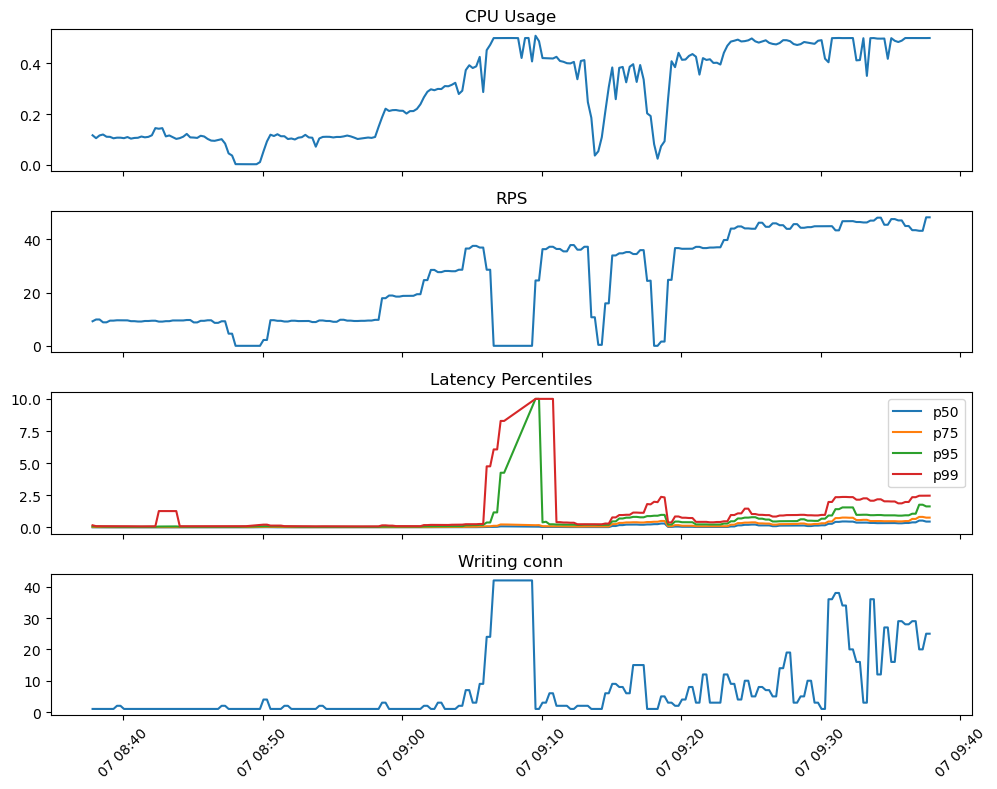

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/baseline/sync-500.csv")
df.rename(columns={"Unnamed: 0": "time"}, inplace=True)
df["time"] = pd.to_datetime(df["time"])

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

# CPU
ax[0].plot(df["time"], df["cpu_usage"])
ax[0].set_title("CPU Usage")

# RPS
ax[1].plot(df["time"], df["ingress_rps_1m"])
ax[1].set_title("RPS")

# Latency (all together)
ax[2].plot(df["time"], df["ingress_p50_latency"], label="p50")
ax[2].plot(df["time"], df["ingress_p75_latency"], label="p75")
ax[2].plot(df["time"], df["ingress_p95_latency"], label="p95")
ax[2].plot(df["time"], df["ingress_p99_latency"], label="p99")
ax[2].set_title("Latency Percentiles")
ax[2].legend()

# Writing conn
ax[3].plot(df["time"], df["nginx_writing_conn"])
ax[3].set_title("Writing conn")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv("./data/request-log.csv")
df.head()

,path,value,timeTaken
0,/prime/kth,433877,26
1,/prime/range,34900,24
2,/prime/check,False,5
3,/prime/kth,164201,7
4,/prime/check,False,5


In [3]:
df.describe()

,timeTaken
count,2013.000000
mean,13.658222
std,14.421427
min,0.000000
25%,5.000000
50%,5.000000
75%,20.000000
max,96.000000
